In [21]:
#!/usr/bin/env python3
# evaluate.py – 自回歸推論 + 圖表  (2025-06-06, final)

# ───────── 使用者參數 ─────────
MODEL_DIR   = "models/20250603_211745"    # best.pt / scaler.pkl / config.json
CSV_PATH    = "data.csv"
START_DATE  = "2025-01-01 06:00"          # 秒可省略
HORIZON     = 14
TARGET_COLS = ["466920氣溫(℃)", "466920降水量(mm)"]
# ────────────────────────────

import os, json, pickle, re, gc, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import dates as mdates

warnings.filterwarnings("ignore", category=UserWarning)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei", "PingFang TC", "Noto Sans CJK TC", "SimHei"
]
plt.rcParams["axes.unicode_minus"] = False

# ══════ 共用函式 ══════
def inverse_standardize(arr_z, scaler, idxs=None):
    if isinstance(arr_z, torch.Tensor):
        arr_z = arr_z.detach().cpu().numpy()
    if idxs is None:
        return arr_z * scaler.scale_ + scaler.mean_
    idxs = np.asarray(idxs)
    if arr_z.shape[1] == len(idxs):
        return arr_z * scaler.scale_[idxs] + scaler.mean_[idxs]
    out = arr_z.copy()
    out[:, idxs] = arr_z[:, idxs] * scaler.scale_[idxs] + scaler.mean_[idxs]
    return out

def restore_temperature(temp_anom, months, clim_mu):
    if isinstance(temp_anom, torch.Tensor):
        temp_anom = temp_anom.detach().cpu().numpy()
    return temp_anom + clim_mu[months - 1]


In [22]:
# ══════ 1. 載入 model / scaler / config ══════
with open(Path(MODEL_DIR) / "config.json", encoding="utf-8") as f:
    cfg = json.load(f)
idxs      = {k: [int(i) for i in v] for k, v in cfg["idxs"].items()}
clim_temp = np.asarray(cfg["clim_temp"])

class PosEnc(torch.nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()
        pos = torch.arange(max_len)[:, None]
        div = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe  = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

class MultiHeadTFM(torch.nn.Module):
    def __init__(self, input_dim, idxs, *, d_model, nhead, num_layers, dim_ff, dropout):
        super().__init__()
        self.idxs = idxs
        self.inp  = torch.nn.Linear(input_dim, d_model)
        self.pos  = PosEnc(d_model)
        self.enc  = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout, batch_first=True),
            num_layers
        )
        self.temp_head   = torch.nn.Linear(d_model, len(idxs["temp"]))
        self.press_head  = torch.nn.Linear(d_model, len(idxs["press"]))
        self.wind_head   = torch.nn.Linear(d_model, len(idxs["wind"]))
        self.other_head  = torch.nn.Linear(d_model, len(idxs["other"]))
        self.pr_cls_head = torch.nn.Linear(d_model, len(idxs["precip"]))
        self.pr_amt_head = torch.nn.Linear(d_model, len(idxs["precip"]))

    def forward(self, x):
        z = self.enc(self.pos(self.inp(x)))[:, -1]
        return {
            "temp" : self.temp_head(z),
            "press": self.press_head(z),
            "wind" : self.wind_head(z),
            "other": self.other_head(z),
            "p_cls": torch.sigmoid(self.pr_cls_head(z)),
            "p_amt": torch.relu(self.pr_amt_head(z))
        }

model = MultiHeadTFM(**{k: v for k, v in cfg.items() if k != "clim_temp"})
model.load_state_dict(torch.load(Path(MODEL_DIR)/"best.pt", map_location=DEVICE))
model.to(DEVICE).eval()
with open(Path(MODEL_DIR)/"scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# ══════ 2. 讀取並前處理 data.csv ══════
df = pd.read_csv(CSV_PATH)
df.rename(columns={df.columns[0]: "Datetime"}, inplace=True)
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.sort_values("Datetime", inplace=True)
df.reset_index(drop=True, inplace=True)

df["month"] = df["Datetime"].dt.month
df["tod"]   = df["Datetime"].dt.hour + df["Datetime"].dt.minute / 60
feats = [c for c in df.columns if c != "Datetime"]

pat_prec    = re.compile("降水量\\(mm\\)")
precip_cols = [c for c in feats if pat_prec.search(c)]
other_cols  = [c for c in feats if c not in precip_cols]

df[precip_cols] = df[precip_cols].mask(df[precip_cols] <= -99, np.nan).fillna(0)
df[other_cols]  = (
    df[other_cols]
    .mask(df[other_cols] <= -99, np.nan)
    .interpolate(limit_direction="both")
)

temp_cols   = [feats[i] for i in idxs["temp"]]
clim_mu_df  = df.groupby("month")[temp_cols].mean()
df[temp_cols] = df[temp_cols] - df["month"].map(clim_mu_df.to_dict("index")).apply(
    lambda d: pd.Series(d)
)

data_z = scaler.transform(df[feats])

# ══════ 3. 找到 START_DATE（允許不完全匹配） ══════
start_ts   = pd.to_datetime(START_DATE)
mask_exact = df["Datetime"] == start_ts
if mask_exact.any():
    start_idx = mask_exact.idxmax()
else:
    mask_after = df["Datetime"] >= start_ts
    if not mask_after.any():
        raise ValueError("資料尾端早於 START_DATE")
    start_idx = mask_after.idxmax()
    real_ts   = df.loc[start_idx, "Datetime"]
    print(f"⚠️ 找不到精確 {START_DATE}，改用最近時間點 {real_ts}")

month_idx = feats.index("month")
tod_idx   = feats.index("tod")

# ══════ 4. 自回歸推論 ══════
last_vec        = data_z[start_idx].astype(np.float32)
pred_list       = []
true_list       = []
time_list       = []
rmse_list       = []

scale_p = torch.tensor(scaler.scale_[idxs["precip"]], dtype=torch.float32, device=DEVICE)
mean_p  = torch.tensor(scaler.mean_[idxs["precip"]],  dtype=torch.float32, device=DEVICE)

for h in range(1, HORIZON + 1):
    if start_idx + h < len(df):
        cur_ts = df.loc[start_idx + h, "Datetime"]
    else:
        cur_ts = time_list[-1] + pd.Timedelta(hours=1)
    cur_month = cur_ts.month
    cur_tod   = cur_ts.hour + cur_ts.minute / 60

    x   = torch.tensor(last_vec[None, None, :], device=DEVICE)
    out = model(x)

    next_vec = last_vec.copy()
    next_vec[idxs["temp"]]  = out["temp"].detach().cpu().numpy()[0]
    next_vec[idxs["press"]] = out["press"].detach().cpu().numpy()[0]
    next_vec[idxs["wind"]]  = out["wind"].detach().cpu().numpy()[0]
    next_vec[idxs["other"]] = out["other"].detach().cpu().numpy()[0]

    # ❶ 把雨量計算留在 GPU，不要一開始就 .cpu()
    rain_raw = (out["p_cls"] > 0.5).float() * out["p_amt"]  # 仍在 DEVICE
    # ❷ (rain_raw - mean_p) / scale_p 也在 GPU 上做，最後才 .cpu().numpy()
    precip_z = ((rain_raw - mean_p) / scale_p).detach().cpu().numpy()[0]
    next_vec[idxs["precip"]] = precip_z

    next_vec[month_idx] = (cur_month - scaler.mean_[month_idx]) / scaler.scale_[month_idx]
    next_vec[tod_idx]   = (cur_tod   - scaler.mean_[tod_idx])   / scaler.scale_[tod_idx]

    tgt_idx  = [feats.index(c) for c in TARGET_COLS]
    pred_raw = inverse_standardize(next_vec[tgt_idx][None, :], scaler, tgt_idx)[0]
    true_raw = inverse_standardize(data_z[start_idx + h, tgt_idx][None, :], scaler, tgt_idx)[0]

    for k, col in enumerate(TARGET_COLS):
        if col.endswith("氣溫(℃)"):
            pos = temp_cols.index(col)
            pred_raw[k] += clim_temp[cur_month - 1, pos]
            true_raw[k] += clim_temp[cur_month - 1, pos]

    pred_list.append(pred_raw)
    true_list.append(true_raw)
    rmse_list.append(np.sqrt((pred_raw - true_raw) ** 2))
    time_list.append(cur_ts)

    last_vec = next_vec

pred_arr = np.stack(pred_list)
true_arr = np.stack(true_list)
rmse_arr = np.stack(rmse_list)
times    = pd.to_datetime(time_list)

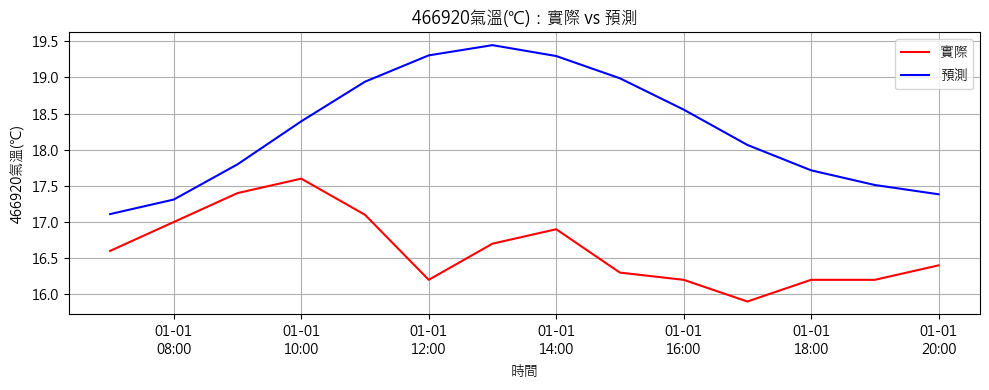

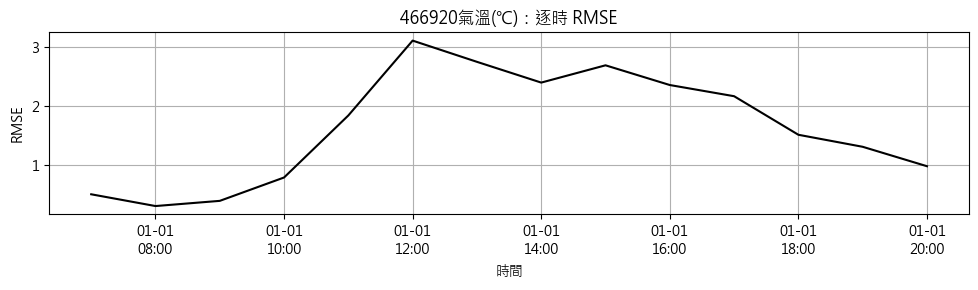

466920氣溫(℃) 逐時 RMSE (前 10 筆): [0.5096803  0.31087998 0.39850607 0.79331489 1.84138393 3.10582702
 2.74723475 2.39656398 2.68856362 2.35540357]


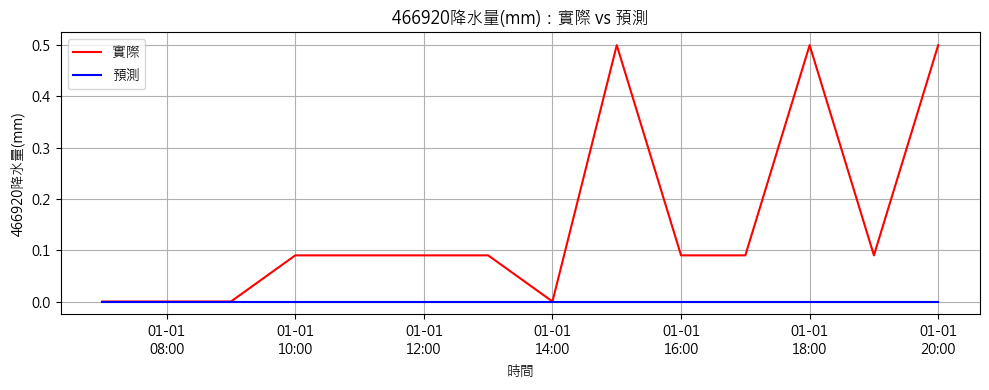

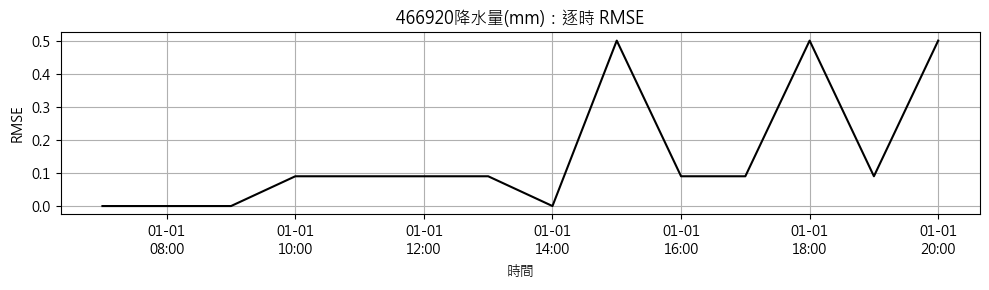

466920降水量(mm) 逐時 RMSE (前 10 筆): [3.09434317e-09 3.09434317e-09 3.09434317e-09 8.99999969e-02
 8.99999969e-02 8.99999969e-02 8.99999969e-02 3.09434317e-09
 4.99999997e-01 8.99999969e-02]
✔️ 推論結束


In [23]:
# ══════ 5. 畫圖 ══════
for j, col in enumerate(TARGET_COLS):
    plt.figure(figsize=(10, 4))
    plt.plot(times, true_arr[:, j], "r-", label="實際")
    plt.plot(times, pred_arr[:, j], "b-", label="預測")
    plt.title(f"{col}：實際 vs 預測")
    plt.xlabel("時間")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(times, rmse_arr[:, j], "k-")
    plt.title(f"{col}：逐時 RMSE")
    plt.xlabel("時間")
    plt.ylabel("RMSE")
    plt.grid(True)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
    plt.tight_layout()
    plt.show()

    print(f"{col} 逐時 RMSE (前 10 筆):", rmse_arr[:10, j])

print("✔️ 推論結束")
gc.collect()
torch.cuda.empty_cache()